In [1]:
import pyzed.sl as sl
import cv2
import numpy as np
import threading
import time
import signal

import time
import threading
import matplotlib.pyplot as plt

In [2]:
zed_list = []
img_list = []
timestamp_list = []
thread_list = []
stop_signal = False

timestamps = {
    'ZED_43957242': [],
    'ZED_43916681': []
}

def signal_handler(signal, frame):
    global stop_signal
    stop_signal=True
    time.sleep(0.5)
    exit()

def grab_run(index):
    global stop_signal
    global zed_list
    global timestamp_list
    global img_list
    global name_list

    runtime = sl.RuntimeParameters()
    while not stop_signal:
        err = zed_list[index].grab(runtime)
        if err == sl.ERROR_CODE.SUCCESS:
            zed_list[index].retrieve_image(img_list[index], sl.VIEW.LEFT)
            current_timestamp = zed_list[index].get_timestamp(sl.TIME_REFERENCE.CURRENT).data_ns
            timestamp_list[index] = current_timestamp
            timestamps[name_list[index]].append(current_timestamp)
        time.sleep(0.0001) #0.1ms
    zed_list[index].close()

def main():
    global stop_signal
    global zed_list
    global img_list
    global timestamp_list
    global thread_list
    global name_list
    signal.signal(signal.SIGINT, signal_handler)

    print("Running...")
    init = sl.InitParameters()
    init.camera_resolution = sl.RESOLUTION.HD1080
    init.camera_fps = 60  # The framerate is lowered to avoid any USB3 bandwidth issues

    #List and open cameras
    name_list = []
    last_ts_list = []
    cameras = sl.Camera.get_device_list()

    index = 0
    for cam in cameras:
        init.set_from_serial_number(cam.serial_number)
        name_list.append(f"ZED_{cam.serial_number}")
        print(f"Opening {name_list[index]}")
        zed_list.append(sl.Camera())
        img_list.append(sl.Mat())
        timestamp_list.append(0)
        last_ts_list.append(0)
        status = zed_list[index].open(init)
        if status != sl.ERROR_CODE.SUCCESS:
            print(repr(status))
            zed_list[index].close()
        index = index +1

    #Start camera threads
    for index in range(0, len(zed_list)):
        if zed_list[index].is_opened():
            thread_list.append(threading.Thread(target=grab_run, args=(index,)))
            thread_list[index].start()
    
    #Display camera images
    key = ''
    while key != 113:  # for 'q' key
        for index in range(0, len(zed_list)):
            if zed_list[index].is_opened():
                if (timestamp_list[index] > last_ts_list[index]):
                    cv2.imshow(name_list[index], cv2.resize(img_list[index].get_data(),(800,600)))

                    last_ts_list[index] = timestamp_list[index]

        key = cv2.waitKey(10)
    cv2.destroyAllWindows()

    #Stop the threads
    stop_signal = True
    for index in range(0, len(thread_list)):
        thread_list[index].join()

    print("\nFINISH")

if __name__ == "__main__":
    main()

Running...
[2025-02-05 15:09:56 UTC][ZED][INFO] Logging level INFO
Opening ZED_43957242
[2025-02-05 15:09:56 UTC][ZED][INFO] Logging level INFO
[2025-02-05 15:09:57 UTC][ZED][INFO] Logging level INFO
[2025-02-05 15:09:57 UTC][ZED][INFO] Logging level INFO
[2025-02-05 15:09:57 UTC][ZED][INFO] Logging level INFO
[2025-02-05 15:09:57 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2025-02-05 15:10:02 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-05 15:10:02 UTC][ZED][INFO] [Init]  Video mode: HD1080@60
[2025-02-05 15:10:02 UTC][ZED][INFO] [Init]  Serial Number: S/N 43957242
Opening ZED_43916681
[2025-02-05 15:10:03 UTC][ZED][INFO] Logging level INFO
[2025-02-05 15:10:03 UTC][ZED][INFO] Logging level INFO
[2025-02-05 15:10:03 UTC][ZED][INFO] Logging level INFO
[2025-02-05 15:10:03 UTC][ZED][INFO] [Init]  Depth mode: PERFORMANCE
[2025-02-05 15:10:07 UTC][ZED][INFO] [Init]  Camera FW version: 2001
[2025-02-05 15:10:07 UTC][ZED][INFO] [Init]  Video mode: HD1080@60
[2025-02-05 15:1

In [7]:
## timestamps in ms for each camera
cam_1_stamps = np.array(timestamps['ZED_43957242'])/1000000
cam_2_stamps = np.array(timestamps['ZED_43916681'])/1000000

# print(timestamps.keys())
print(f'cam1 stamps: {cam_1_stamps.shape}')
print(f'cam2 stamps: {cam_2_stamps.shape}')

cam1 stamps: (3528,)
cam2 stamps: (3552,)


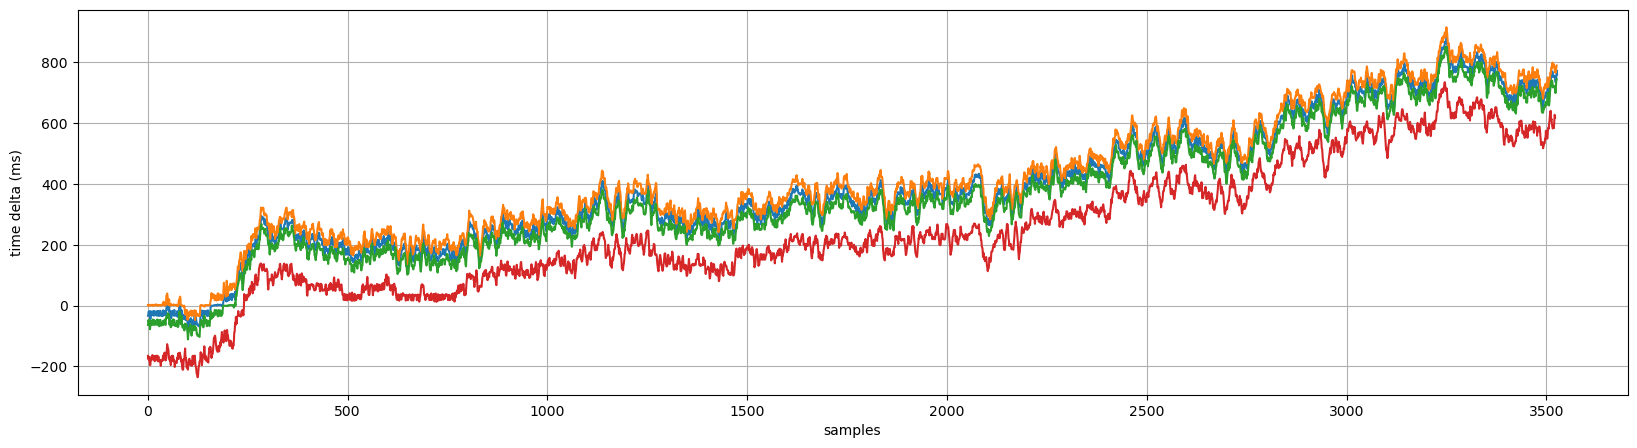

In [15]:
shorter_end_idx = min([len(cam_1_stamps),len(cam_2_stamps)])

diff_no_shift = cam_1_stamps[:shorter_end_idx]-cam_2_stamps[:shorter_end_idx]

diff_1_shift = np.delete(cam_1_stamps[:shorter_end_idx],0)-cam_2_stamps[:shorter_end_idx-1]

diff_other1_shift = cam_1_stamps[:shorter_end_idx-1] - np.delete(cam_2_stamps[:shorter_end_idx],0)

diff_other5shift = cam_1_stamps[:shorter_end_idx-5] - cam_2_stamps[5:shorter_end_idx]

plt.figure(figsize=(20,5))
plt.plot(diff_no_shift)
plt.plot(diff_1_shift)
plt.plot(diff_other1_shift)
plt.plot(diff_other5shift)
plt.ylabel('time delta (ms)')
plt.xlabel('samples')
plt.grid()